# 투구 제구 성공 확률 모델 평가

`main.ipynb`가 만든 시간순 OOF 예측을 평가합니다. 모델을 다시 학습하지 않으며, 주 평가는 해당 연도보다 앞선 OOF만으로 블렌딩·보정한 `pred_calibrated_walk_forward`입니다.

In [1]:
from pathlib import Path
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import log_loss, mean_squared_error, roc_auc_score

ROOT = Path.cwd().resolve()
RUN_DIR = Path(os.environ.get("BASEBALL_RUN_DIR", ROOT)).resolve()
ARTIFACT_DIR = RUN_DIR / "artifacts"
MODEL_DIR = RUN_DIR / "model"
OOF_PATH = ARTIFACT_DIR / "oof_predictions.parquet"
if not OOF_PATH.exists():
    raise FileNotFoundError("먼저 main.ipynb를 끝까지 실행해 주세요.")

oof = pd.read_parquet(OOF_PATH)
cv_metrics = pd.read_csv(ARTIFACT_DIR / "cv_metrics.csv")
importance = pd.read_csv(ARTIFACT_DIR / "feature_importance.csv")
feature_config = json.loads((MODEL_DIR / "feature_config.json").read_text(encoding="utf-8"))
print(f"OOF rows={len(oof):,}, seasons={sorted(oof['season'].unique())}")
display(cv_metrics.sort_values(["season", "model"]))


OOF rows=746,504, seasons=[np.int16(2022), np.int16(2023), np.int16(2024)]


,season,model,rows,brier,brier_skill_train_prior,log_loss,roc_auc,target_mean,prediction_mean,best_iteration
0,2022,constant_train_prior,247472,0.249366,0.000000,0.691880,0.500000,0.528920,0.543142,0
5,2022,game_type,247472,0.243549,0.023326,0.679920,0.576570,0.528920,0.530050,0
1,2022,global_long,247472,0.243547,0.023333,0.679903,0.576980,0.528920,0.534869,161
2,2022,global_recent,247472,0.243545,0.023344,0.679906,0.577652,0.528920,0.535623,107
3,2022,global_seasonless,247472,0.243623,0.023031,0.680100,0.578307,0.528920,0.531363,90
4,2022,pitcher,247472,0.244109,0.021081,0.681104,0.573348,0.528920,0.529218,87
18,2022,walk_forward_blend,247472,0.243529,0.023408,0.679884,0.577868,0.528920,0.532225,0
19,2022,walk_forward_calibrated,247472,0.243529,0.023408,0.679884,0.577868,0.528920,0.532225,0
6,2023,constant_train_prior,245525,0.251567,0.000000,0.696290,0.500000,0.499957,0.539537,0
11,2023,game_type,245525,0.249140,0.009646,0.691423,0.532945,0.499957,0.504160,0


## 1. Fold별 확률 예측 지표

Brier가 주 지표입니다. Brier Skill은 해당 검증 시즌 이전 학습 라벨의 평균을 상수로 예측한 기준선과 비교합니다.

In [2]:
TARGET = "control_success"
PREDICTION_COLUMNS = {
    "Global long": "pred_global_long",
    "Global recent": "pred_global_recent",
    "Global seasonless": "pred_global_seasonless",
    "Game-type expert": "pred_game_type",
    "Pitcher expert": "pred_pitcher",
    "Walk-forward blend": "pred_blend_walk_forward",
    "Walk-forward calibrated": "pred_calibrated_walk_forward",
    "Final-fit calibrated (optimistic)": "pred_calibrated_final_fit",
}

def expected_calibration_error(y_true, prediction, bins=15):
    y_true = np.asarray(y_true)
    prediction = np.asarray(prediction)
    edges = np.linspace(0.0, 1.0, bins + 1)
    groups = np.clip(np.digitize(prediction, edges[1:-1]), 0, bins-1)
    ece = 0.0
    for index in range(bins):
        mask = groups == index
        if mask.any():
            ece += mask.mean() * abs(prediction[mask].mean() - y_true[mask].mean())
    return float(ece)

def season_prior(season):
    return float(feature_config["season_prior_map"][str(int(season))])

rows = []
for season, part in oof.groupby("season", sort=True):
    y = part[TARGET].to_numpy()
    prior = season_prior(season)
    baseline = mean_squared_error(y, np.full(len(y), prior))
    for label, column in PREDICTION_COLUMNS.items():
        prediction = np.clip(part[column].to_numpy(dtype="float64"), 1e-5, 1-1e-5)
        score = mean_squared_error(y, prediction)
        rows.append({
            "season": int(season), "model": label, "rows": len(part),
            "brier": score, "brier_skill_train_prior": 1-score/baseline,
            "log_loss": log_loss(y, prediction),
            "roc_auc": roc_auc_score(y, prediction),
            "ece_15": expected_calibration_error(y, prediction),
            "target_mean": y.mean(), "prediction_mean": prediction.mean(),
            "mean_gap": prediction.mean()-y.mean(),
        })
summary = pd.DataFrame(rows)
summary.to_csv(ARTIFACT_DIR / "evaluation_summary.csv", index=False, encoding="utf-8")
display(summary.style.format({"brier": "{:.6f}", "brier_skill_train_prior": "{:.4f}", "log_loss": "{:.6f}", "roc_auc": "{:.4f}", "ece_15": "{:.5f}", "target_mean": "{:.5f}", "prediction_mean": "{:.5f}", "mean_gap": "{:+.5f}"}))


,season,model,rows,brier,brier_skill_train_prior,log_loss,roc_auc,ece_15,target_mean,prediction_mean,mean_gap
0,2022,Global long,247472,0.243547,0.0233,0.679903,0.5770,0.01109,0.52892,0.53487,+0.00595
1,2022,Global recent,247472,0.243545,0.0233,0.679906,0.5777,0.01216,0.52892,0.53562,+0.00670
2,2022,Global seasonless,247472,0.243623,0.0230,0.680100,0.5783,0.01279,0.52892,0.53136,+0.00244
3,2022,Game-type expert,247472,0.243549,0.0233,0.679920,0.5766,0.00726,0.52892,0.53005,+0.00113
4,2022,Pitcher expert,247472,0.244109,0.0211,0.681104,0.5733,0.00884,0.52892,0.52922,+0.00030
5,2022,Walk-forward blend,247472,0.243529,0.0234,0.679884,0.5779,0.01096,0.52892,0.53222,+0.00330
6,2022,Walk-forward calibrated,247472,0.243529,0.0234,0.679884,0.5779,0.01096,0.52892,0.53222,+0.00330
7,2022,Final-fit calibrated (optimistic),247472,0.243426,0.0238,0.679654,0.5771,0.00500,0.52892,0.52713,-0.00179
8,2023,Global long,245525,0.249944,0.0064,0.693035,0.5220,0.00267,0.49996,0.50263,+0.00267
9,2023,Global recent,245525,0.249953,0.0064,0.693054,0.5218,0.00254,0.49996,0.50249,+0.00254


## 2. 시즌 안정성과 calibration

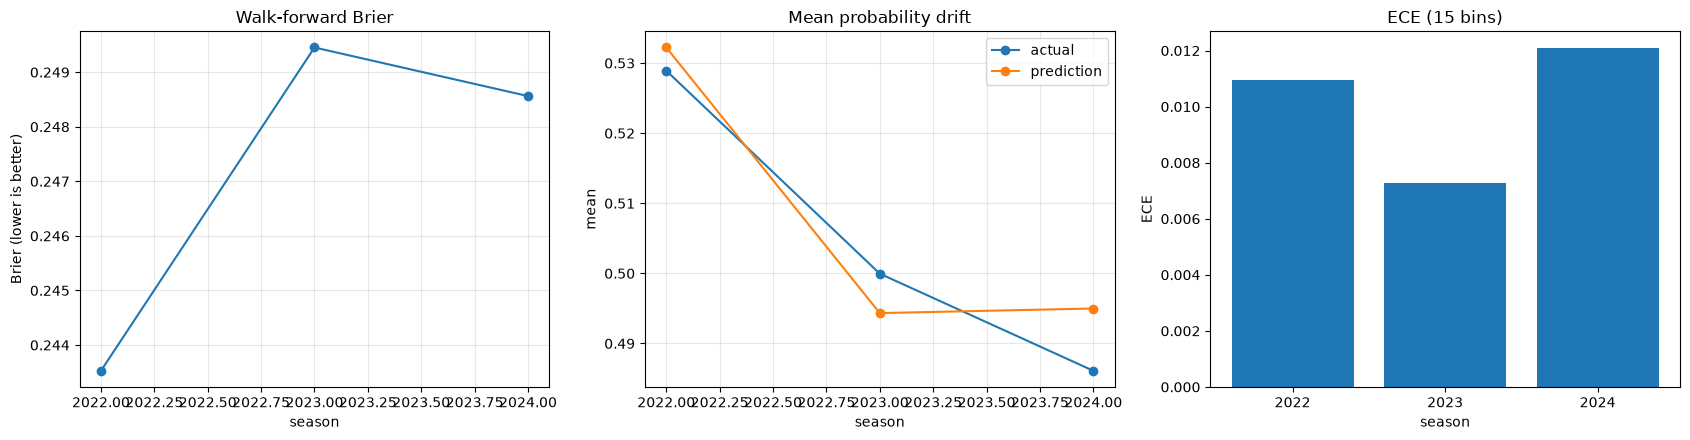

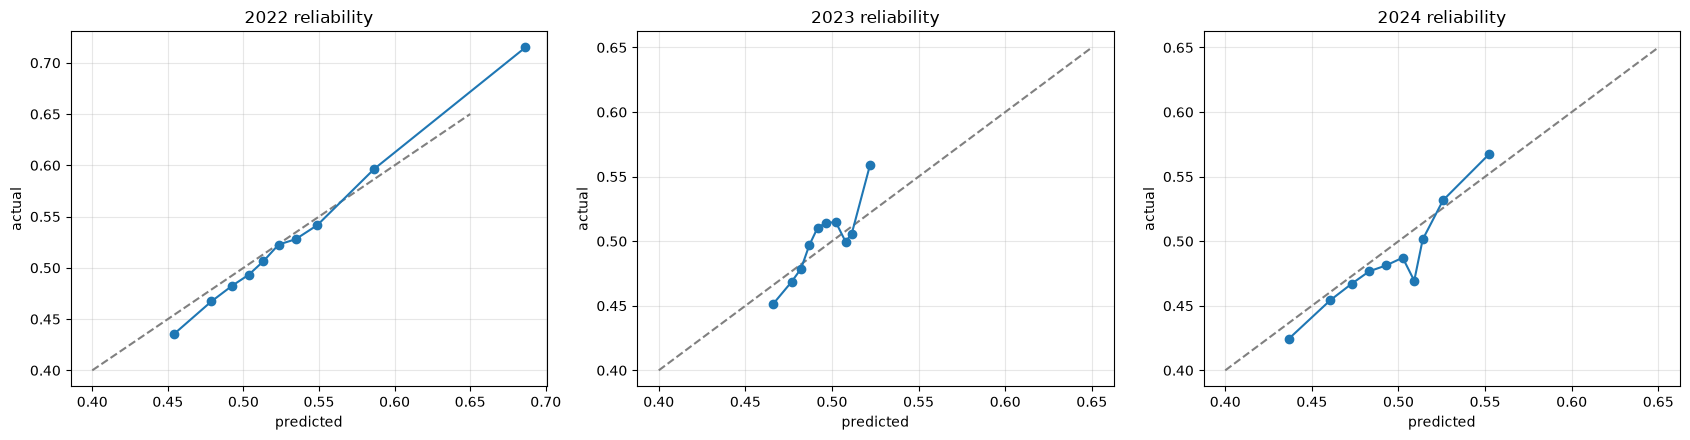

In [3]:
primary = summary[summary["model"] == "Walk-forward calibrated"].copy()
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
axes[0].plot(primary["season"], primary["brier"], marker="o")
axes[0].set(title="Walk-forward Brier", xlabel="season", ylabel="Brier (lower is better)")
axes[0].grid(alpha=0.3)
axes[1].plot(primary["season"], primary["target_mean"], marker="o", label="actual")
axes[1].plot(primary["season"], primary["prediction_mean"], marker="o", label="prediction")
axes[1].set(title="Mean probability drift", xlabel="season", ylabel="mean")
axes[1].legend(); axes[1].grid(alpha=0.3)
axes[2].bar(primary["season"].astype(str), primary["ece_15"])
axes[2].set(title="ECE (15 bins)", xlabel="season", ylabel="ECE")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for axis, (season, part) in zip(axes, oof.groupby("season", sort=True)):
    prediction = part["pred_calibrated_walk_forward"].to_numpy()
    y = part[TARGET].to_numpy()
    bins = pd.qcut(prediction, q=10, duplicates="drop")
    reliability = pd.DataFrame({"prediction": prediction, "target": y, "bin": bins}).groupby("bin", observed=True).agg(prediction=("prediction", "mean"), actual=("target", "mean"), rows=("target", "size"))
    axis.plot([0.4, 0.65], [0.4, 0.65], linestyle="--", color="gray")
    axis.plot(reliability["prediction"], reliability["actual"], marker="o")
    axis.set(title=f"{season} reliability", xlabel="predicted", ylabel="actual")
    axis.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 3. 경기 유형·cold-start·이력 표본별 평가

In [4]:
oof["pitcher_history_bin"] = pd.cut(
    oof["asof_pitcher_n"], bins=[-1, 0, 49, 199, 999, np.inf],
    labels=["0", "1-49", "50-199", "200-999", "1000+"],
)
oof["pitcher_cold_start"] = np.where(oof["asof_pitcher_n"] == 0, "cold", "seen")

def slice_scores(frame, columns, prediction_column="pred_calibrated_walk_forward"):
    records = []
    for keys, part in frame.groupby(columns, observed=True, sort=True):
        if len(part) < 100:
            continue
        keys = keys if isinstance(keys, tuple) else (keys,)
        prediction = np.clip(part[prediction_column], 1e-5, 1-1e-5)
        record = dict(zip(columns, keys))
        record.update(rows=len(part), brier=mean_squared_error(part[TARGET], prediction), target_mean=part[TARGET].mean(), prediction_mean=prediction.mean())
        records.append(record)
    return pd.DataFrame(records)

game_type_scores = slice_scores(oof, ["season", "game_type"])
history_scores = slice_scores(oof, ["season", "pitcher_history_bin"])
cold_start_scores = slice_scores(oof, ["season", "pitcher_cold_start"])
display(game_type_scores)
display(history_scores)
display(cold_start_scores)
game_type_scores.to_csv(ARTIFACT_DIR / "evaluation_by_game_type.csv", index=False, encoding="utf-8")
history_scores.to_csv(ARTIFACT_DIR / "evaluation_by_pitcher_history.csv", index=False, encoding="utf-8")


,season,game_type,rows,brier,target_mean,prediction_mean
0,2022,F,30448,0.207173,0.708749,0.676916
1,2022,R,217024,0.248629,0.503691,0.511925
2,2023,F,25686,0.250524,0.472904,0.509119
3,2023,R,219839,0.249328,0.503118,0.492608
4,2024,F,30010,0.250791,0.459280,0.510190
5,2024,R,223497,0.248263,0.489707,0.492947


,season,pitcher_history_bin,rows,brier,target_mean,prediction_mean
0,2022,1-49,3915,0.236545,0.563218,0.571395
1,2022,50-199,10494,0.234472,0.564227,0.562921
2,2022,200-999,45640,0.238947,0.553922,0.548122
3,2022,1000+,187335,0.245297,0.520127,0.525790
4,2023,1-49,3066,0.250083,0.471298,0.498401
5,2023,50-199,8285,0.249340,0.464816,0.491399
6,2023,200-999,33688,0.249820,0.484089,0.489006
7,2023,1000+,200423,0.249386,0.504538,0.495288
8,2024,1-49,3899,0.249421,0.457040,0.496036
9,2024,50-199,10572,0.248999,0.464907,0.490768


,season,pitcher_cold_start,rows,brier,target_mean,prediction_mean
0,2022,seen,247384,0.243528,0.528915,0.532207
1,2023,seen,245462,0.249453,0.499976,0.494333
2,2024,seen,253426,0.248562,0.486130,0.494985


## 4. 피처 중요도와 최종 체크

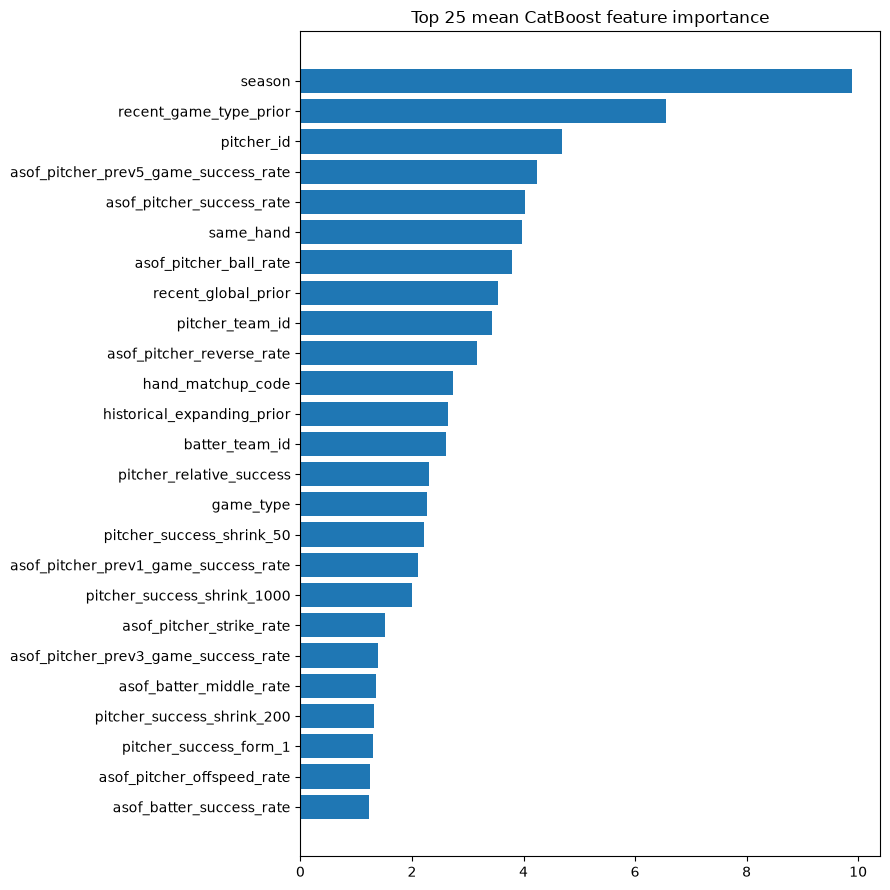

latest season=2024, Brier=0.248563, mean gap=+0.008884
worst season=2023, Brier=0.249453
최신 시즌 평균 calibration 오차가 1%p 이내입니다.
평가 표가 artifacts/evaluation_*.csv에 저장되었습니다.


In [5]:
top = importance.sort_values("mean_importance", ascending=False).head(25).sort_values("mean_importance")
plt.figure(figsize=(9, 9))
plt.barh(top["feature"], top["mean_importance"])
plt.title("Top 25 mean CatBoost feature importance")
plt.tight_layout(); plt.show()

latest = primary.loc[primary["season"] == primary["season"].max()].iloc[0]
worst = primary.loc[primary["brier"].idxmax()]
print(f"latest season={int(latest['season'])}, Brier={latest['brier']:.6f}, mean gap={latest['mean_gap']:+.6f}")
print(f"worst season={int(worst['season'])}, Brier={worst['brier']:.6f}")
if abs(latest["mean_gap"]) > 0.01:
    print("주의: 최신 시즌 평균 calibration 오차가 1%p를 넘습니다.")
else:
    print("최신 시즌 평균 calibration 오차가 1%p 이내입니다.")
print("평가 표가 artifacts/evaluation_*.csv에 저장되었습니다.")
